# QPA Fidelity Decay — Dynamic Circuit — IBM Pittsburgh

This notebook runs the full QPA experiment pipeline using **dynamic circuits** on `ibm_pittsburgh`.

1. **Configuration** — Define experiment parameters
2. **Backend Setup** — Connect to IBM Quantum hardware (`ibm_pittsburgh`)
3. **Circuit Generation** — Build dynamic circuits with `HybridStrategy` (N=3) and `HybridStrategy_n5_ntrials_1` (N=5, flat if)
4. **Transpilation** — N=3: unrolled-layout strategy; N=5: static-layout strategy (extract layout from the if branch)
5. **Noise Application** — Apply Pauli Twirling noise for each λ point
6. **Submission** — Send circuits to IBM and collect results
7. **Result Processing** — Extract counts and compute fidelity
8. **Plotting** — Compare experimental fidelity decay against theory

**Experiments:**
- N=3, K=2, T=1 (3 registers, 2 qubits each, 1 trial round)
- N=5, K=2, T=1 (5 registers, 2 qubits each, 1 trial round — flat if strategy)

**Sampling budget:** N_RANDOM × N_PUBS = 4000 × 4 = 16000 total samples per λ point.

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# Add dynamic_experiment to path so we can import HybridStrategy and utils
sys.path.insert(0, os.path.join(os.getcwd(), "dynamic_experiment"))

from qpa_engine import HybridStrategy, HybridStrategy_n5_ntrials_1
from utils import (
    transpile_dynamic_best_of_n_unrolled,
    transpile_dynamic_best_of_n,
    get_static_depth,
)

from core.noise_models import PauliTwirlingStrategy
from execution.backend_handler import IBMRuntimeHandler
from analysis.result_processor import ResultProcessor
from analysis.fidelity_calc import calculate_success_rate

from qiskit.circuit import CircuitInstruction
from qiskit.circuit.library import XGate, RZGate
from qiskit_ibm_runtime import SamplerV2 as IBMSampler

print("Imports loaded.")

Imports loaded.


## Step 1: Configuration

| Parameter | Description | Value |
|-----------|-------------|-------|
| `N` | Number of registers (must be odd) | 3, 5 |
| `K` | Qubits per register (qudit dimension d=2^k) | 2 |
| `T` (n_trials) | Number of QPA trial rounds | 1 |
| `POINTS` | Number of λ (noise) values to sweep | 25 |
| `LAMBDA_MIN/MAX` | Noise parameter range | 0.0 – 1.0 |
| `N_RANDOM` | Pauli twirling instances per λ point | 4000 |
| `SHOTS` | Shots (pubs) per circuit instance | 4 |
| `BATCH_SIZE` | Circuits per IBM job submission | 50 |
| `N_SEEDS` | Number of transpiler seeds to try (best-of-N) | 20 |
| `DEVICE` | IBM Quantum backend | ibm_pittsburgh |

In [2]:
# ----- Experiment Parameters -----
K = 2                # Qubits per register (d = 2^K = 4)
T = 1                # Number of QPA trial rounds
POINTS = 25          # Number of lambda values in the sweep
LAMBDA_MIN = 0.0     # Minimum noise parameter
LAMBDA_MAX = 1.0     # Maximum noise parameter
N_RANDOM = 4000      # Pauli twirling instances per circuit (ensemble size)
SHOTS = 4            # Shots (pubs) per circuit instance
BATCH_SIZE = 50      # Max circuits per job submission
N_SEEDS = 20         # Number of transpiler seeds to try (best-of-N)
DEVICE = "ibm_pittsburgh"  # IBM Quantum backend

# The two experiments
EXPERIMENTS = [
    {"n": 3, "k": K, "t": T, "label": "N=3, K=2, T=1"},
    {"n": 5, "k": K, "t": T, "label": "N=5, K=2, T=1"},
]

# Derived
lambdas = np.linspace(LAMBDA_MIN, LAMBDA_MAX, POINTS)

print(f"Lambda sweep: {POINTS} points from {LAMBDA_MIN} to {LAMBDA_MAX}")
print(f"Shots per circuit instance: {SHOTS}")
print(f"Pauli twirling instances per lambda: {N_RANDOM}")
print(f"Total samples per lambda: {N_RANDOM * SHOTS}")
print(f"Transpiler seeds to try: {N_SEEDS}")
print(f"Experiments: {[e['label'] for e in EXPERIMENTS]}")

Lambda sweep: 25 points from 0.0 to 1.0
Shots per circuit instance: 4
Pauli twirling instances per lambda: 4000
Total samples per lambda: 16000
Transpiler seeds to try: 20
Experiments: ['N=3, K=2, T=1', 'N=5, K=2, T=1']


## Step 2: Backend Setup

Connect to `ibm_pittsburgh` via `QiskitRuntimeService`.

In [3]:
# Initialize the IBM Runtime backend handler
backend_handler = IBMRuntimeHandler(backend_name=DEVICE)
backend = backend_handler.get_backend()

print(f"Backend: {backend.name}")
print(f"Number of qubits: {backend.num_qubits}")
print(f"Backend status: {backend.status()}")

qiskit_runtime_service._discover_account:WARNING:2026-03-12 23:49:32,334: Loading account with the given token. A saved account will not be used.


Connecting to IBM Runtime Service via channel='ibm_cloud'...
Backend: ibm_pittsburgh
Number of qubits: 156
Backend status: <qiskit_ibm_runtime.models.backend_status.BackendStatus object at 0x119f0d010>


## Step 3: Circuit Generation (Dynamic Circuits)

For **N=3**, we use the standard **HybridStrategy** which builds a single dynamic circuit with `if_test` branching. With T=1, there is only one level of nesting.

For **N=5**, we use **HybridStrategy_n5_ntrials_1** which builds a flat (non-nested) `if_test` on the 2-bit classical register value.

In [4]:
# Build golden (noiseless) dynamic circuits for each experiment
golden_per_exp = {}

for exp in EXPERIMENTS:
    n = exp["n"]
    label = exp["label"]
    
    if n == 5:
        # Use flat-if strategy for N=5
        strategy = HybridStrategy_n5_ntrials_1(k=K)
    else:
        strategy = HybridStrategy(k=K, n_trials=T, n_registers=n)
    
    qc_dynamic = strategy.build_circuit(epsilon=0.0)
    
    golden_per_exp[n] = {
        'circuit': qc_dynamic,
        'strategy': strategy,
    }
    
    print(f"\n--- {label} ---")
    print(f"  Strategy: {type(strategy).__name__}")
    print(f"  Qubits: {qc_dynamic.num_qubits}")
    print(f"  Classical bits: {qc_dynamic.num_clbits}")
    print(f"  Depth: {qc_dynamic.depth()}")
    print(f"  Gate counts: {dict(qc_dynamic.count_ops())}")


--- N=3, K=2, T=1 ---
  Strategy: HybridStrategy
  Qubits: 8
  Classical bits: 4
  Depth: 7
  Gate counts: {'measure': 3, 'h': 2, 'cswap': 2, 'if_else': 2, 'reset': 1}

--- N=5, K=2, T=1 ---
  Strategy: HybridStrategy_n5_ntrials_1
  Qubits: 13
  Classical bits: 5
  Depth: 9
  Gate counts: {'h': 4, 'cswap': 4, 'measure': 4, 'if_else': 3, 'reset': 2}


### Visualize a sample circuit

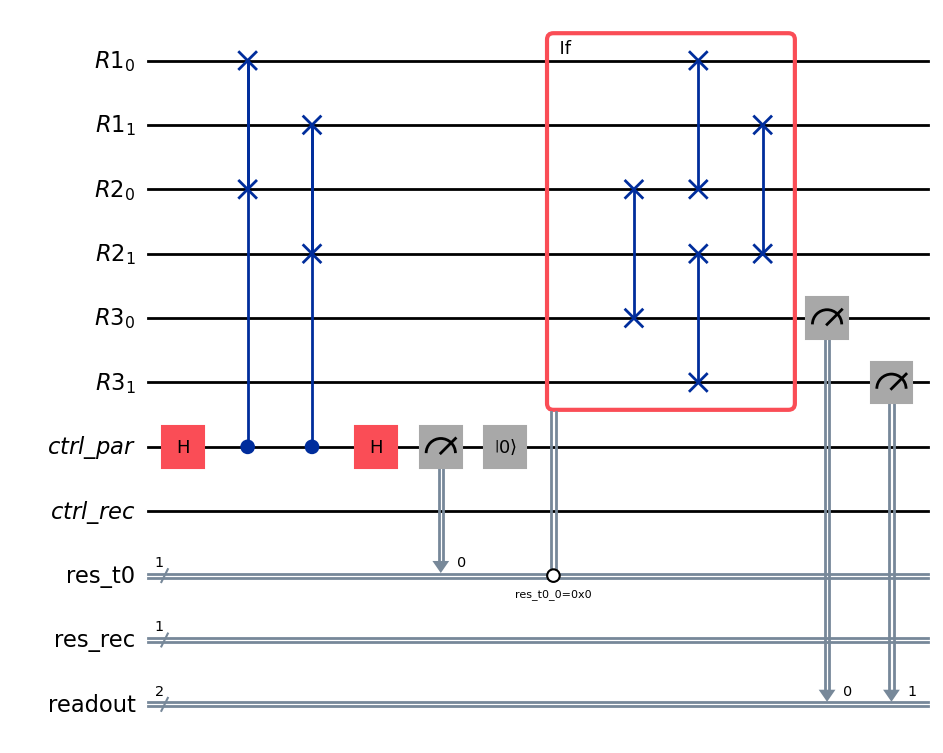

In [5]:
sample_qc = golden_per_exp[3]['circuit']
sample_qc.draw('mpl', fold=120)

## Step 4: Transpilation

**N=3 — Unrolled-layout strategy:**
1. Build the longest unrolled path with registers matching the dynamic circuit
2. Transpile that static circuit to extract a good initial layout
3. Re-transpile the dynamic circuit using that layout

**N=5 — Static-layout strategy:**
1. Extract the static **if** branch from the dynamic circuit (longest path)
2. Transpile that static proxy to extract a good initial layout
3. Re-transpile the dynamic circuit using that layout

Best-of-N seeds for both.

In [6]:
def filter_2q(inst):
    """Filter for 2-qubit gates only (used for depth evaluation)."""
    return inst.operation.num_qubits == 2

transpiled_per_exp = {}

for exp in EXPERIMENTS:
    n = exp["n"]
    label = exp["label"]
    qc_dynamic = golden_per_exp[n]['circuit']
    qc_dynamic = qc_dynamic.decompose(reps=5)
    
    print(f"\nTranspiling dynamic circuit for {label} (best-of-{N_SEEDS} seeds)...")
    
    if n == 5:
        # N=5: static-layout strategy using the if branch
        BRANCH = 'if'
        result = transpile_dynamic_best_of_n(
            qc_dynamic, backend,
            branch=BRANCH,
            optimization_level=3,
            n_trials=N_SEEDS,
            depth_branch=BRANCH,
            filter_fn=filter_2q,
        )
    else:
        # N=3: unrolled-layout strategy
        result = transpile_dynamic_best_of_n_unrolled(
            qc_dynamic, backend,
            k=K, n_trials_qpa=T, n_registers=n,
            optimization_level=3,
            n_trials=N_SEEDS,
            depth_branch='if',
            filter_fn=filter_2q,
        )
    
    transpiled_per_exp[n] = result['circuit']
    
    print(f"  Best seed: {result['seed']}")
    print(f"  Best 2Q depth: {result['best_depth']}")
    print(f"  Avg 2Q depth: {result['avg_depth']:.1f}")
    print(f"  All depths: {result['all_depths']}")
    
    qc_tr = result['circuit']
    print(f"  Transpiled circuit: depth={qc_tr.depth()}, gates={dict(qc_tr.count_ops())}")

print("\nAll dynamic circuits transpiled.")


Transpiling dynamic circuit for N=3, K=2, T=1 (best-of-20 seeds)...
  Best seed: 9
  Best 2Q depth: 36
  Avg 2Q depth: 90.3
  All depths: [(0, 87), (1, 93), (2, 111), (3, 123), (4, 129), (5, 111), (6, 111), (7, 105), (8, 69), (9, 36), (10, 57), (11, 75), (12, 111), (13, 78), (14, 117), (15, 57), (16, 117), (17, 75), (18, 75), (19, 69)]
  Transpiled circuit: depth=62, gates={'sx': 44, 'rz': 29, 'cz': 20, 'x': 3, 'measure': 3, 'if_else': 2, 'reset': 1}

Transpiling dynamic circuit for N=5, K=2, T=1 (best-of-20 seeds)...
  Best seed: 1
  Best 2Q depth: 33
  Avg 2Q depth: 47.7
  All depths: [(0, 36), (1, 33), (2, 61), (3, 33), (4, 48), (5, 39), (6, 36), (7, 71), (8, 39), (9, 34), (10, 39), (11, 59), (12, 60), (13, 57), (14, 57), (15, 39), (16, 73), (17, 54), (18, 47), (19, 39)]
  Transpiled circuit: depth=70, gates={'sx': 94, 'rz': 59, 'cz': 43, 'x': 5, 'measure': 4, 'if_else': 3, 'reset': 2}

All dynamic circuits transpiled.


## Step 5: Noise Application & Circuit Instance Generation

For each λ value and each Pauli twirling instance, we:
1. Copy the transpiled golden dynamic circuit
2. Generate random Pauli noise operations
3. Insert them at the beginning of the circuit (fast path)

Pauli gates (Z, Y) are converted to ISA-safe gates (RZ, X+RZ) for IBM hardware.

In [7]:
def build_noisy_dynamic_batch(transpiled_golden, golden_circuit, epsilon, n_random, batch_size):
    """
    Build batches of noisy dynamic circuit instances from a pre-transpiled golden circuit.
    """
    all_batches = []
    batch_circuits = []
    
    data_regs = [reg for reg in golden_circuit.qregs if reg.name.startswith("R")]
    layout = transpiled_golden.layout.initial_layout if transpiled_golden.layout else None
    
    for _ in range(n_random):
        noise_strategy = PauliTwirlingStrategy(K)
        qc_instance = transpiled_golden.copy()
        
        noise_ops = noise_strategy.generate_noise_ops(data_regs, epsilon)
        
        for gate, logical_qubit in noise_ops:
            target_qubit = None
            if layout and logical_qubit in layout:
                phys_qubit_idx = layout[logical_qubit]
                target_qubit = qc_instance.qubits[phys_qubit_idx]
            elif logical_qubit in qc_instance.qubits:
                target_qubit = logical_qubit
            else:
                for q in qc_instance.qubits:
                    if hasattr(q, 'register') and hasattr(logical_qubit, 'register'):
                        if q.register.name == logical_qubit.register.name and q.index == logical_qubit.index:
                            target_qubit = q
                            break
            
            if target_qubit:
                if gate.name == 'z':
                    qc_instance.data.insert(0, CircuitInstruction(RZGate(np.pi), (target_qubit,), ()))
                elif gate.name == 'y':
                    qc_instance.data.insert(0, CircuitInstruction(RZGate(np.pi), (target_qubit,), ()))
                    qc_instance.data.insert(0, CircuitInstruction(XGate(), (target_qubit,), ()))
                else:
                    qc_instance.data.insert(0, CircuitInstruction(gate, (target_qubit,), ()))
        
        batch_circuits.append(qc_instance)
        
        if len(batch_circuits) >= batch_size:
            all_batches.append(batch_circuits)
            batch_circuits = []
    
    if batch_circuits:
        all_batches.append(batch_circuits)
    
    return all_batches

# Quick test
test_batches = build_noisy_dynamic_batch(
    transpiled_per_exp[3],
    golden_per_exp[3]['circuit'],
    epsilon=0.5, n_random=2, batch_size=50
)
total_circuits = sum(len(b) for b in test_batches)
print(f"Test: epsilon=0.5, N=3, 2 instances -> {total_circuits} circuits in {len(test_batches)} batch(es)")

Test: epsilon=0.5, N=3, 2 instances -> 2 circuits in 1 batch(es)


## Step 6: Submission to IBM Quantum

For each experiment (N=3 and N=5), sweep over all λ values. At each λ:
1. Generate `N_RANDOM` noisy dynamic circuit instances (fast path)
2. Submit them in batches to `ibm_pittsburgh`
3. Wait for results and compute fidelity

In [8]:
def run_dynamic_experiment(n, transpiled_golden, golden_circuit,
                           lambdas, n_random, shots_per_circuit, batch_size, backend):
    """
    Run the full lambda sweep for one dynamic circuit experiment.
    """
    result_processor = ResultProcessor(K)
    results = []
    
    sampler = IBMSampler(mode=backend)
    total_clbits = golden_circuit.num_clbits
    
    for epsilon in tqdm(lambdas, desc=f"N={n} lambda sweep"):
        batches = build_noisy_dynamic_batch(
            transpiled_golden, golden_circuit,
            epsilon, n_random, batch_size
        )
        
        total_success = 0
        total_shots = 0
        
        for batch_idx, batch_circs in enumerate(batches):
            pubs = [(qc, None, shots_per_circuit) for qc in batch_circs]
            
            try:
                job = sampler.run(pubs)
                pub_result = job.result()
                
                extracted_counts = ResultProcessor.extract_counts_from_job_result(pub_result, is_dynamic=True)
                
                for counts in extracted_counts:
                    shots = sum(counts.values())
                    success = calculate_success_rate(counts, K, total_clbits)
                    total_success += success
                    total_shots += shots
                    
            except Exception as e:
                print(f"  Error at lambda={epsilon:.4f}, batch {batch_idx}: {e}")
                import traceback
                traceback.print_exc()
        
        fidelity = total_success / total_shots if total_shots > 0 else 0.0
        
        results.append({'lambda': epsilon, 'fidelity': fidelity})
        print(f"  N={n}, lambda={epsilon:.4f} -> fidelity={fidelity:.4f}")
    
    return results

print("run_dynamic_experiment() defined.")

run_dynamic_experiment() defined.


### Run Experiment: N=3, K=2, T=1 (Dynamic Circuit)

In [9]:
results_n3 = run_dynamic_experiment(
    n=3,
    transpiled_golden=transpiled_per_exp[3],
    golden_circuit=golden_per_exp[3]['circuit'],
    lambdas=lambdas,
    n_random=N_RANDOM,
    shots_per_circuit=SHOTS,
    batch_size=BATCH_SIZE,
    backend=backend
)

df_n3 = pd.DataFrame(results_n3)
print(f"\nN=3 results: {len(df_n3)} lambda points collected")
df_n3.head()

N=3 lambda sweep:   0%|          | 0/25 [00:00<?, ?it/s]

  N=3, lambda=0.0000 -> fidelity=0.9269
  N=3, lambda=0.0417 -> fidelity=0.9119
  N=3, lambda=0.0833 -> fidelity=0.8938
  Error at lambda=0.1250, batch 0: 'Unable to retrieve job result. Error code 8056; Failed to execute program: A control instrument error occurred. -- https://ibm.biz/error_codes#8056'


Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_59957/149379309.py", line 26, in run_dynamic_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 131, in result
    raise RuntimeJobFailureError(f"Unable to retrieve job result. {error_message}")
qiskit_ibm_runtime.exceptions.RuntimeJobFailureError: 'Unable to retrieve job result. Error code 8056; Failed to execute program: A control instrument error occurred. -- https://ibm.biz/error_codes#8056'


  N=3, lambda=0.1250 -> fidelity=0.8792
  N=3, lambda=0.1667 -> fidelity=0.8542
  N=3, lambda=0.2083 -> fidelity=0.8343
  N=3, lambda=0.2500 -> fidelity=0.8143
  N=3, lambda=0.2917 -> fidelity=0.7914
  N=3, lambda=0.3333 -> fidelity=0.7643
  N=3, lambda=0.3750 -> fidelity=0.7398
  N=3, lambda=0.4167 -> fidelity=0.7008
  N=3, lambda=0.4583 -> fidelity=0.6826
  N=3, lambda=0.5000 -> fidelity=0.6504
  N=3, lambda=0.5417 -> fidelity=0.6256
  N=3, lambda=0.5833 -> fidelity=0.5836
  N=3, lambda=0.6250 -> fidelity=0.5579
  N=3, lambda=0.6667 -> fidelity=0.5258
  Error at lambda=0.7083, batch 17: '401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d6pv4msu243c739vjn9g?exclude_params=true. {"errors":[{"code":1219,"message":"Error authenticating user.","solution":"Your IBM Quantum API token might be incorrect, expired, or revoked.\\nLog in to IBM Quantum Platform website and navigate to your account settings to generate a new API token.\\nUse IBMProvider.save_accou

Traceback (most recent call last):
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/api/session.py", line 327, in request
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/requests/models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 401 Client Error: Unauthorized for url: https://quantum.cloud.ibm.com/api/v1/jobs/d6pv4msu243c739vjn9g?exclude_params=true

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/var/folders/jt/44gl1rhd26v6ykt0frqzl87r0000gn/T/ipykernel_59957/149379309.py", line 26, in run_dynamic_experiment
    pub_result = job.result()
  File "/Users/henryzou/.venvs/opqa/lib/python3.13/site-packages/qiskit_ibm_runtime/runtime_job_v2.py", line 126, in result
    self.wait_for_final_state(timeout=timeout)
    ~~~~~~~~~~~~~~~~~~~~~~~

  N=3, lambda=0.7083 -> fidelity=0.4931
  N=3, lambda=0.7500 -> fidelity=0.4527
  N=3, lambda=0.7917 -> fidelity=0.4294
  N=3, lambda=0.8333 -> fidelity=0.3992
  N=3, lambda=0.8750 -> fidelity=0.3676
  N=3, lambda=0.9167 -> fidelity=0.3275
  N=3, lambda=0.9583 -> fidelity=0.2936
  N=3, lambda=1.0000 -> fidelity=0.2629

N=3 results: 25 lambda points collected


,lambda,fidelity
0,0.000000,0.926875
1,0.041667,0.911875
2,0.083333,0.893750
3,0.125000,0.879177
4,0.166667,0.854187


### Run Experiment: N=5, K=2, T=1 (Dynamic Circuit — Flat If)

In [10]:
results_n5 = run_dynamic_experiment(
    n=5,
    transpiled_golden=transpiled_per_exp[5],
    golden_circuit=golden_per_exp[5]['circuit'],
    lambdas=lambdas,
    n_random=N_RANDOM,
    shots_per_circuit=SHOTS,
    batch_size=BATCH_SIZE,
    backend=backend
)

df_n5 = pd.DataFrame(results_n5)
print(f"\nN=5 results: {len(df_n5)} lambda points collected")
df_n5.head()

N=5 lambda sweep:   0%|          | 0/25 [00:00<?, ?it/s]

  N=5, lambda=0.0000 -> fidelity=0.9408
  N=5, lambda=0.0417 -> fidelity=0.9238
  N=5, lambda=0.0833 -> fidelity=0.9051
  N=5, lambda=0.1250 -> fidelity=0.8858
  N=5, lambda=0.1667 -> fidelity=0.8702
  N=5, lambda=0.2083 -> fidelity=0.8541
  N=5, lambda=0.2500 -> fidelity=0.8210
  N=5, lambda=0.2917 -> fidelity=0.8070
  N=5, lambda=0.3333 -> fidelity=0.7799
  N=5, lambda=0.3750 -> fidelity=0.7543
  N=5, lambda=0.4167 -> fidelity=0.7212
  N=5, lambda=0.4583 -> fidelity=0.7027
  N=5, lambda=0.5000 -> fidelity=0.6752
  N=5, lambda=0.5417 -> fidelity=0.6326
  N=5, lambda=0.5833 -> fidelity=0.6069
  N=5, lambda=0.6250 -> fidelity=0.5714
  N=5, lambda=0.6667 -> fidelity=0.5378
  N=5, lambda=0.7083 -> fidelity=0.4998
  N=5, lambda=0.7500 -> fidelity=0.4576
  N=5, lambda=0.7917 -> fidelity=0.4178
  N=5, lambda=0.8333 -> fidelity=0.3887
  N=5, lambda=0.8750 -> fidelity=0.3580
  N=5, lambda=0.9167 -> fidelity=0.3301
  N=5, lambda=0.9583 -> fidelity=0.2928
  N=5, lambda=1.0000 -> fidelity=0.2664


,lambda,fidelity
0,0.000000,0.940813
1,0.041667,0.923813
2,0.083333,0.905125
3,0.125000,0.885750
4,0.166667,0.870250


## Step 7: Save Results

In [11]:
results_dir = os.path.join("data", "results", "end_to_end_dynamic_pittsburgh")
os.makedirs(results_dir, exist_ok=True)

csv_n3 = os.path.join(results_dir, "results_n3_k2_t1_dynamic_ibm_pittsburgh.csv")
csv_n5 = os.path.join(results_dir, "results_n5_k2_t1_dynamic_ibm_pittsburgh.csv")

df_n3.to_csv(csv_n3, index=False)
df_n5.to_csv(csv_n5, index=False)

print(f"N=3 results saved to: {csv_n3}")
print(f"N=5 results saved to: {csv_n5}")

N=3 results saved to: data/results/end_to_end_dynamic_pittsburgh/results_n3_k2_t1_dynamic_ibm_pittsburgh.csv
N=5 results saved to: data/results/end_to_end_dynamic_pittsburgh/results_n5_k2_t1_dynamic_ibm_pittsburgh.csv


## Step 8: Plotting — Experimental vs. Theory

**Theoretical curves** (for K=2, d=4):
- N=3: $F(\lambda) = \frac{1}{8}(8 - 2\lambda - 7\lambda^2 + 3\lambda^3)$
- N=5: $F(\lambda) = \frac{1}{640}(640 - 96\lambda - 224\lambda^2 - 700\lambda^3 + 693\lambda^4 - 153\lambda^5)$

Plot saved to: data/results/end_to_end_dynamic_pittsburgh/fidelity_decay_dynamic_t1_ibm_pittsburgh.png


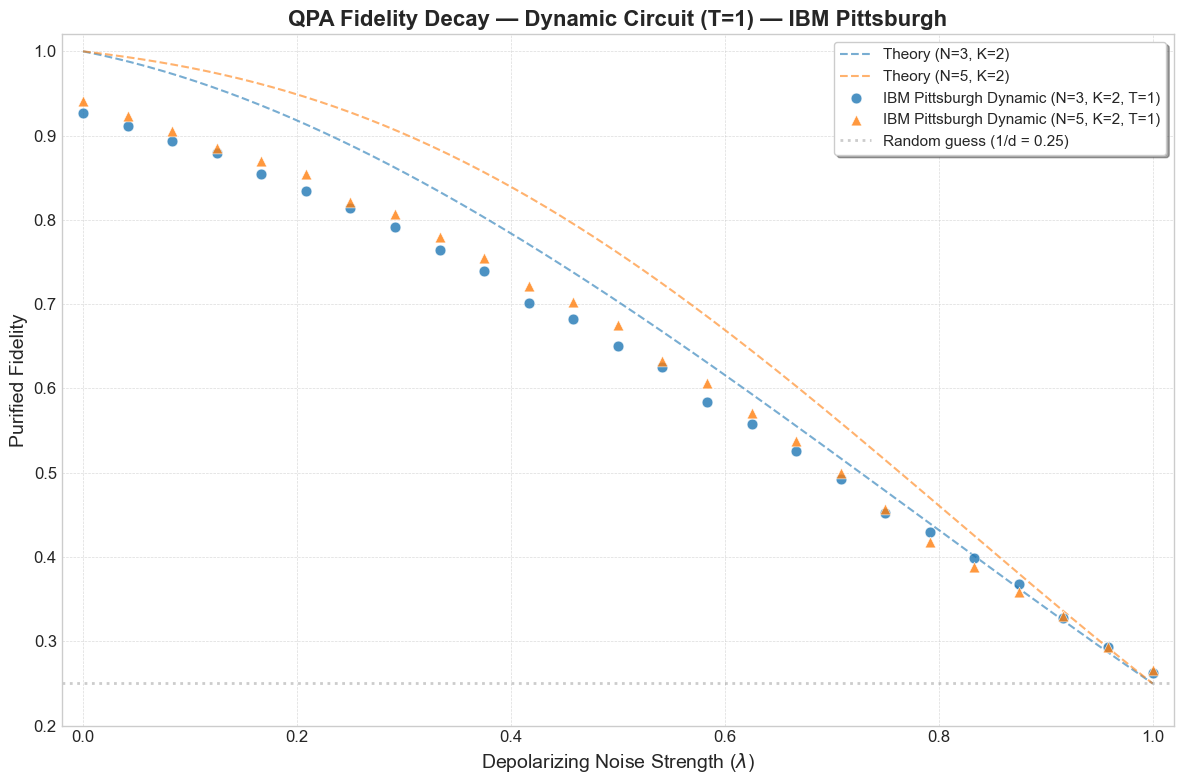

In [12]:
def theory_curve(lam, n, k):
    if k == 2:
        if n == 3:
            return (1/8) * (8 - 2*lam - 7*lam**2 + 3*lam**3)
        elif n == 5:
            return (1/640) * (640 - 96*lam - 224*lam**2 - 700*lam**3 + 693*lam**4 - 153*lam**5)
    return None

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 16,
    'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11,
    'lines.linewidth': 2, 'lines.markersize': 8
})

fig, ax = plt.subplots(figsize=(12, 8))

lam_fine = np.linspace(0, 1, 200)
colors = {'n3': '#1f77b4', 'n5': '#ff7f0e'}

theory_n3 = theory_curve(lam_fine, 3, 2)
theory_n5 = theory_curve(lam_fine, 5, 2)
ax.plot(lam_fine, theory_n3, '--', color=colors['n3'], linewidth=1.5, alpha=0.6, label='Theory (N=3, K=2)')
ax.plot(lam_fine, theory_n5, '--', color=colors['n5'], linewidth=1.5, alpha=0.6, label='Theory (N=5, K=2)')

ax.scatter(df_n3['lambda'], df_n3['fidelity'], color=colors['n3'], marker='o', s=60,
           zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
           label=f'IBM Pittsburgh Dynamic (N=3, K=2, T=1)')
ax.scatter(df_n5['lambda'], df_n5['fidelity'], color=colors['n5'], marker='^', s=60,
           zorder=5, alpha=0.8, edgecolors='white', linewidth=0.5,
           label=f'IBM Pittsburgh Dynamic (N=5, K=2, T=1)')

ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.4, label='Random guess (1/d = 0.25)')

ax.set_title('QPA Fidelity Decay — Dynamic Circuit (T=1) — IBM Pittsburgh', fontweight='bold')
ax.set_xlabel(r'Depolarizing Noise Strength ($\lambda$)')
ax.set_ylabel('Purified Fidelity')
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(0.20, 1.02)
ax.legend(loc='best', frameon=True, shadow=True)
ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()

plot_path = os.path.join(results_dir, "fidelity_decay_dynamic_t1_ibm_pittsburgh.png")
plt.savefig(plot_path, dpi=300)
print(f"Plot saved to: {plot_path}")

plt.show()

## Step 9: Result Inspection

In [13]:
print("=== N=3, K=2, T=1 ===")
print(f"{'Lambda':>8} {'Exp Fidelity':>14} {'Theory':>10} {'Delta':>10}")
print("-" * 46)
for _, row in df_n3.iterrows():
    lam = row['lambda']
    exp_f = row['fidelity']
    th_f = theory_curve(lam, 3, 2)
    delta = exp_f - th_f if th_f is not None else float('nan')
    print(f"{lam:8.4f} {exp_f:14.4f} {th_f:10.4f} {delta:+10.4f}")

print(f"\n=== N=5, K=2, T=1 ===")
print(f"{'Lambda':>8} {'Exp Fidelity':>14} {'Theory':>10} {'Delta':>10}")
print("-" * 46)
for _, row in df_n5.iterrows():
    lam = row['lambda']
    exp_f = row['fidelity']
    th_f = theory_curve(lam, 5, 2)
    delta = exp_f - th_f if th_f is not None else float('nan')
    print(f"{lam:8.4f} {exp_f:14.4f} {th_f:10.4f} {delta:+10.4f}")

=== N=3, K=2, T=1 ===
  Lambda   Exp Fidelity     Theory      Delta
----------------------------------------------
  0.0000         0.9269     1.0000    -0.0731
  0.0417         0.9119     0.9881    -0.0762
  0.0833         0.8938     0.9733    -0.0796
  0.1250         0.8792     0.9558    -0.0766
  0.1667         0.8542     0.9358    -0.0816
  0.2083         0.8343     0.9133    -0.0791
  0.2500         0.8143     0.8887    -0.0744
  0.2917         0.7914     0.8620    -0.0705
  0.3333         0.7643     0.8333    -0.0690
  0.3750         0.7398     0.8030    -0.0632
  0.4167         0.7008     0.7711    -0.0702
  0.4583         0.6826     0.7377    -0.0551
  0.5000         0.6504     0.7031    -0.0527
  0.5417         0.6256     0.6675    -0.0419
  0.5833         0.5836     0.6309    -0.0473
  0.6250         0.5579     0.5935    -0.0356
  0.6667         0.5258     0.5556    -0.0297
  0.7083         0.4931     0.5172    -0.0241
  0.7500         0.4527     0.4785    -0.0258
  0.7917   